In [5]:
import pandas as pd 
import numpy as np

df = pd.read_csv('House Price India.csv')

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

In [6]:
df = df.fillna(df.median(numeric_only=True))

In [11]:
#Q1

mean_price = df['Price'].mean()
median_price = df['Price'].median()
std_price = df['Price'].std()

print("Mean:", mean_price)
print("Median:", median_price)
print("Std Dev:", std_price)

Mean: 538932.2183310534
Median: 450000.0
Std Dev: 367532.3808039669


In [14]:
#Q2

most_common_bedrooms = df['number of bedrooms'].mode()[0]
print("Most common bedrooms:", most_common_bedrooms)

df['number of bedrooms'].value_counts()

Most common bedrooms: 3


number of bedrooms
3     6612
4     4724
2     1844
5     1079
6      176
1      136
7       30
8       11
9        3
10       3
33       1
11       1
Name: count, dtype: int64

In [16]:
#Q3

price_skew = df['Price'].skew()
print("Skewness of price:", price_skew)

Skewness of price: 4.269297720707117


In [18]:
#Q4

avg_price_by_bedrooms = df.groupby('number of bedrooms')['Price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

number of bedrooms
8     1.208455e+06
7     1.016544e+06
6     8.375815e+05
10    8.200000e+05
9     7.766663e+05
5     7.752550e+05
33    6.400000e+05
4     6.361988e+05
11    5.200000e+05
3     4.632776e+05
2     3.985476e+05
1     3.089638e+05
Name: Price, dtype: float64


In [20]:
#Q5

correlation = df['Area of the house(excluding basement)'].corr(df['Price'])
print("Correlation between Area (excl. basement) and Price:", correlation)

Correlation between Area (excl. basement) and Price: 0.6152204198678111


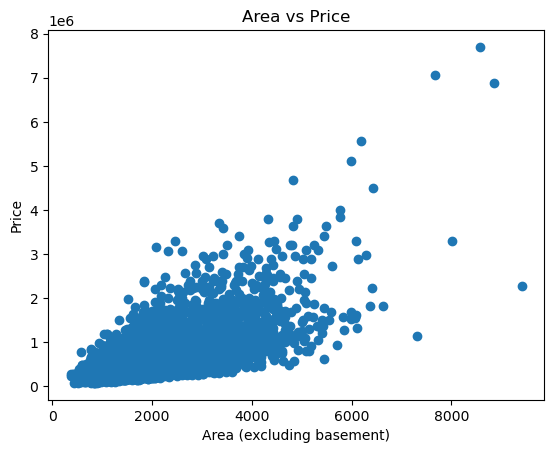

In [22]:
import matplotlib.pyplot as plt
plt.scatter(df['Area of the house(excluding basement)'], df['Price'])
plt.xlabel('Area (excluding basement)')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [23]:
#Q6

area_threshold = df['Area of the house(excluding basement)'].quantile(0.25)
price_threshold = df['Price'].quantile(0.75)

anomalies = df[(df['Area of the house(excluding basement)'] < area_threshold) & (df['Price'] > price_threshold)]
print("Number of anomalies:", len(anomalies))
anomalies[['Area of the house(excluding basement)', 'Price']]

Number of anomalies: 139


,Area of the house(excluding basement),Price
101,1050,657100
174,930,675000
176,1160,650000
258,980,690000
353,1150,712000
...,...,...
14024,1000,930000
14034,780,664950
14277,1080,650000
14482,780,659000


In [24]:
#Q7

avg_price_by_floors = df.groupby('number of floors')['Price'].mean()
print(avg_price_by_floors)

avg_price_by_waterfront = df.groupby('waterfront present')['Price'].mean()
print(avg_price_by_waterfront)

number of floors
1.0    4.369769e+05
1.5    5.549301e+05
2.0    6.487372e+05
2.5    1.106233e+06
3.0    5.663281e+05
3.5    1.205875e+06
Name: Price, dtype: float64
waterfront present
0    5.304174e+05
1    1.641902e+06
Name: Price, dtype: float64


In [25]:
#Q8

min_price = df['Price'].min()
max_price = df['Price'].max()

print("Minimum Price:", min_price)
print("Maximum Price:", max_price)

Minimum Price: 78000
Maximum Price: 7700000


In [27]:
#Q9

avg_price_by_zip = df.groupby('Postal Code')['Price'].mean().sort_values(ascending=False)
print(avg_price_by_zip.head(1))   # top location
print(avg_price_by_zip.head(10))  # top 10 locations 

Postal Code
122071    2.348311e+06
Name: Price, dtype: float64
Postal Code
122071    2.348311e+06
122048    1.296414e+06
122057    1.188517e+06
122047    1.069295e+06
122061    8.895896e+05
122013    8.855842e+05
122003    8.503290e+05
122004    8.398533e+05
122027    8.296322e+05
122049    8.035388e+05
Name: Price, dtype: float64
